<a href="https://colab.research.google.com/github/ronan-cunha/machine-learning-course/blob/main/Notebooks/regress%C3%A3o_linear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Configuração de semente para reproducibilidade
np.random.seed(42)
n = 200

# Gerando variáveis explicativas
preco = np.random.uniform(10, 50, n)
renda = np.random.uniform(1000, 5000, n)
gasto_mkt = np.random.uniform(100, 1000, n)
gasto_digital = gasto_mkt * 0.85 + np.random.normal(0, 20, n)

# Gerando a quantidade demandada com relação não linear
# Q = 100 - 1.5*Preco + 0.02*Renda + 0.5*sqrt(Mkt) + erro
erro = np.random.normal(0, 5, n)
qtd = 100 - 1.5 * preco + 0.02 * renda + 15 * np.log(gasto_mkt) + erro

df = pd.DataFrame({
    'qtd': qtd,
    'preco': preco,
    'renda': renda,
    'gasto_mkt': gasto_mkt,
    'gasto_digital': gasto_digital
})

df.head()

,qtd,preco,renda,gasto_mkt,gasto_digital
0,225.682618,24.981605,3568.126585,192.811482,153.284607
1,157.223925,48.028572,1336.559860,912.297616,759.595517
2,168.857452,39.279758,1646.514856,554.727135,469.377458
3,241.913141,33.946339,4594.216754,843.811719,696.535115
4,234.560436,16.240746,3425.716239,388.044641,318.764959


In [13]:
modelo_nivel_nivel = smf.ols('qtd ~ preco + renda', data=df).fit()
print(modelo_nivel_nivel.summary())

                            OLS Regression Results                            
Dep. Variable:                    qtd   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     744.2
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.50e-92
Time:                        18:23:38   Log-Likelihood:                -756.90
No. Observations:                 200   AIC:                             1520.
Df Residuals:                     197   BIC:                             1530.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    198.7184      2.864     69.388      0.0

In [15]:
# Ajuste do modelo Log-Log
modelo_lognivel = smf.ols('np.log(qtd) ~ preco + renda', data=df).fit()
print(modelo_lognivel.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(qtd)   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.871
Method:                 Least Squares   F-statistic:                     675.4
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           6.54e-89
Time:                        18:24:12   Log-Likelihood:                 298.53
No. Observations:                 200   AIC:                            -591.1
Df Residuals:                     197   BIC:                            -581.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2834      0.015    361.251      0.0

In [16]:
# Ajuste do modelo Log-Log
modelo_loglog = smf.ols('np.log(qtd) ~ np.log(preco) + np.log(renda)', data=df).fit()
print(modelo_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:            np.log(qtd)   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.831
Method:                 Least Squares   F-statistic:                     489.9
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           3.48e-77
Time:                        18:24:22   Log-Likelihood:                 271.12
No. Observations:                 200   AIC:                            -536.2
Df Residuals:                     197   BIC:                            -526.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.1613      0.084     49.555

In [18]:
# Criando modelo com duas variáveis muito correlacionadas (gasto_mkt e gasto_digital)
X = df[['preco', 'renda', 'gasto_mkt', 'gasto_digital']]
X_const = sm.add_constant(X)

# Cálculo do VIF para cada variável
vif_data = pd.DataFrame()
vif_data["Variável"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

print(vif_data)

        Variável         VIF
0          const    1.000000
1          preco    1.003400
2          renda    1.022022
3      gasto_mkt  138.131489
4  gasto_digital  138.344982


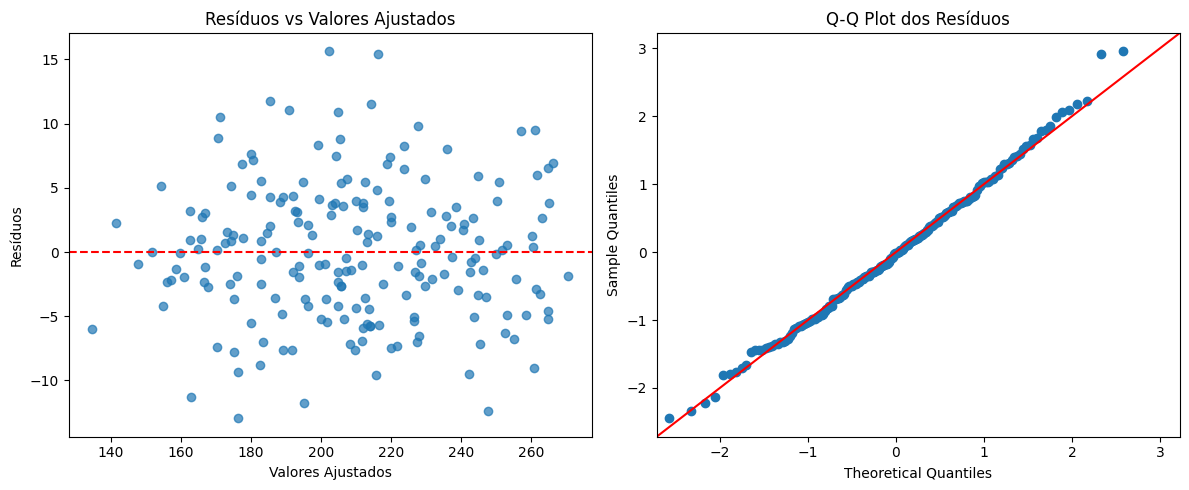

In [7]:
# Estimando modelo base
modelo = smf.ols('qtd ~ preco + renda + gasto_mkt', data=df).fit()

# Extraindo resíduos e valores ajustados
residuos = modelo.resid
valores_ajustados = modelo.fittedvalues

# Configurando o painel de diagnósticos visuais
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Homocedasticidade: Resíduos vs Valores Ajustados
axes[0].scatter(valores_ajustados, residuos, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Resíduos vs Valores Ajustados')
axes[0].set_xlabel('Valores Ajustados')
axes[0].set_ylabel('Resíduos')

# 2. Normalidade: Q-Q Plot
sm.qqplot(residuos, line='45', fit=True, ax=axes[1])
axes[1].set_title('Q-Q Plot dos Resíduos')

plt.tight_layout()
plt.show()

In [8]:
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

# Teste de Normalidade de Shapiro-Wilk (H0: resíduos são normais)
stat_shapiro, p_shapiro = shapiro(residuos)
print(f'Shapiro-Wilk: p-valor = {p_shapiro:.4f}')

# Teste de Homocedasticidade de Breusch-Pagan (H0: resíduos são homocedásticos)
bp_test = het_breuschpagan(residuos, modelo.model.exog)
print(f'Breusch-Pagan: p-valor = {bp_test[1]:.4f}')

Shapiro-Wilk: p-valor = 0.7800
Breusch-Pagan: p-valor = 0.9207
